In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L1_VCF     = os.path.expanduser("/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/LINE1.filtered.vcf.gz")
ALU_VCF    = os.path.expanduser("/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/ALU.filtered.vcf.gz")
OUTDIR_LEN = os.path.expanduser("/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/Results/Basic_Analysis")
os.makedirs(OUTDIR_LEN, exist_ok=True)

In [13]:
%%bash
source ~/.bashrc
conda activate rnaseq_r
module load bcftools-1.21

L1_VCF=/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/LINE1.filtered.vcf.gz
ALU_VCF=/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/ALU.filtered.vcf.gz
OUTDIR_LEN=/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/Results/Basic_Analysis

bcftools query -f '%INFO/SVLEN\n' $L1_VCF \
  | awk '$1 != -1 {print $1}' > $OUTDIR_LEN/LINE1_lengths.txt

bcftools query -f '%INFO/SVLEN\t%INFO/ISTP\n' $L1_VCF | awk '{
  svlen=$1; istp=$2
  if (svlen==-1) { if (istp>0) print 6019-istp }
  else print svlen
}' > $OUTDIR_LEN/LINE1_lengths_istp.txt

bcftools query -f '%INFO/SVLEN\n' $ALU_VCF \
  | awk '$1 != -1 {print $1}' > $OUTDIR_LEN/ALU_lengths.txt

echo "LINE1 (SVLEN):   $(wc -l < $OUTDIR_LEN/LINE1_lengths.txt)"
echo "LINE1 (ISTP):    $(wc -l < $OUTDIR_LEN/LINE1_lengths_istp.txt)"
echo "ALU:             $(wc -l < $OUTDIR_LEN/ALU_lengths.txt)"

[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G


LINE1 (SVLEN):   5295
LINE1 (ISTP):    7093
ALU:             26990


In [14]:
def load_lengths(path):
    vals = pd.read_csv(path, header=None, names=["length"])["length"]
    vals = pd.to_numeric(vals, errors="coerce").abs().dropna()
    return vals[vals > 0].reset_index(drop=True)

l1_reg  = load_lengths(f"{OUTDIR_LEN}/LINE1_lengths.txt")
l1_istp = load_lengths(f"{OUTDIR_LEN}/LINE1_lengths_istp.txt")
alu     = load_lengths(f"{OUTDIR_LEN}/ALU_lengths.txt")

In [15]:
for label, arr in [("LINE1 (SVLEN only)", l1_reg),
                   ("LINE1 (ISTP imputed)", l1_istp),
                   ("ALU", alu)]:
    print(f"=== {label} ===")
    print(f"  N:      {len(arr)}")
    print(f"  Mean:   {arr.mean():.2f} bp")
    print(f"  Median: {arr.median():.1f} bp\n")

=== LINE1 (SVLEN only) ===
  N:      5295
  Mean:   3265.91 bp
  Median: 2844.0 bp

=== LINE1 (ISTP imputed) ===
  N:      7093
  Mean:   2749.55 bp
  Median: 1603.0 bp

=== ALU ===
  N:      26990
  Mean:   264.83 bp
  Median: 280.0 bp



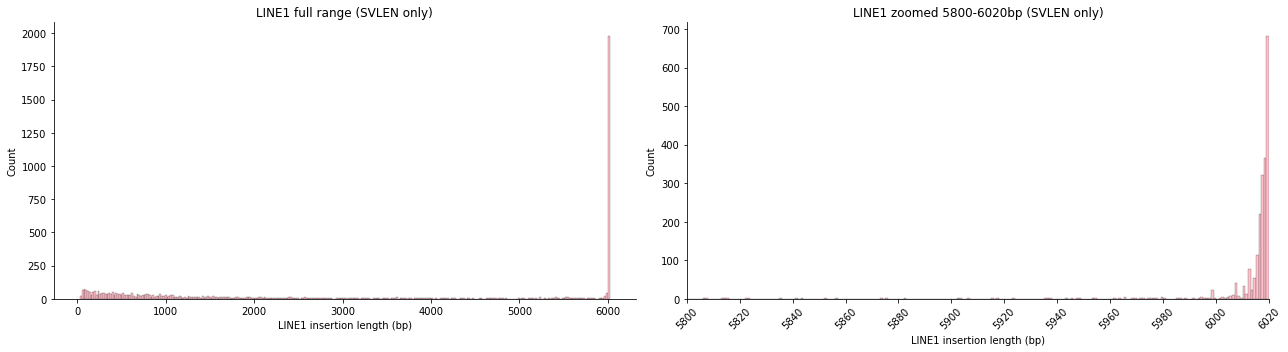

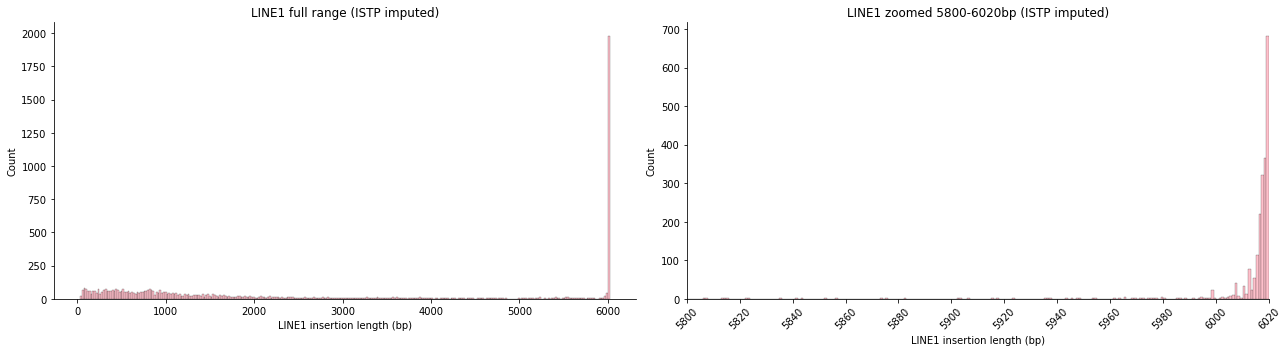

In [16]:
def plot_l1(lengths, label, prefix):
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    axes[0].hist(lengths, bins=300, color="pink", edgecolor="black", linewidth=0.2)
    axes[0].set_xlabel("LINE1 insertion length (bp)")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"LINE1 full range ({label})")
    axes[0].spines[["top","right"]].set_visible(False)

    axes[1].hist(lengths, bins=range(5800, 6021, 1), color="pink", edgecolor="black", linewidth=0.2)
    axes[1].set_xlim(5800, 6020)
    axes[1].set_xticks(range(5800, 6021, 20))
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_xlabel("LINE1 insertion length (bp)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"LINE1 zoomed 5800-6020bp ({label})")
    axes[1].spines[["top","right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(f"{OUTDIR_LEN}/{prefix}.png", dpi=150)
    plt.show()

plot_l1(l1_reg,  "SVLEN only",   "LINE1_svlen")
plot_l1(l1_istp, "ISTP imputed", "LINE1_istp")

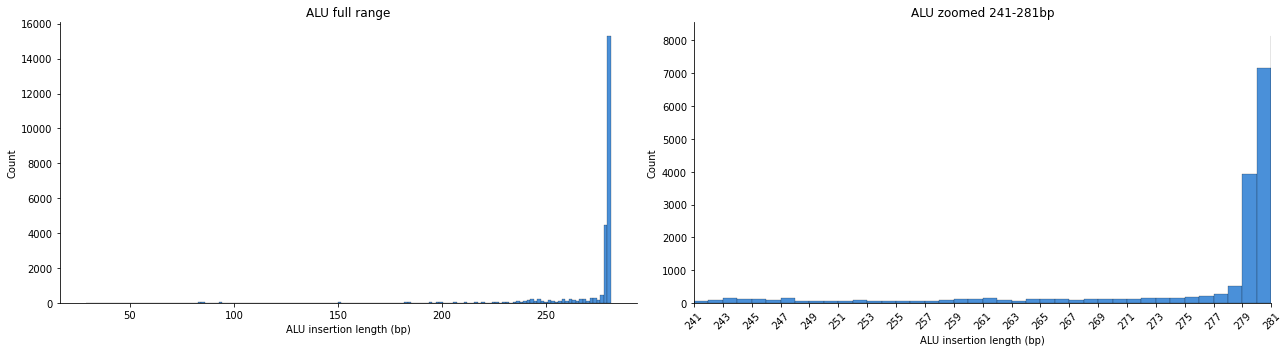

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].hist(alu, bins=150, color="#4a90d9", edgecolor="black", linewidth=0.2)
axes[0].set_xlabel("ALU insertion length (bp)")
axes[0].set_ylabel("Count")
axes[0].set_title("ALU full range")
axes[0].spines[["top","right"]].set_visible(False)

axes[1].hist(alu, bins=range(241, 283, 1), color="#4a90d9", edgecolor="black", linewidth=0.2)
axes[1].set_xlim(241, 281)
axes[1].set_xticks(range(241, 282, 2))
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xlabel("ALU insertion length (bp)")
axes[1].set_ylabel("Count")
axes[1].set_title("ALU zoomed 241-281bp")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTDIR_LEN}/ALU_length_histogram.png", dpi=150)
plt.show()